In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
risk_scores = pd.read_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/risk_scores.csv"
)

risk_scores['Date'] = pd.to_datetime(risk_scores['Date'])

risk_scores.set_index('Date', inplace=True)

# Financial Shock Scenarios

The simulation engine models hypothetical macroeconomic and geopolitical events that impact commodity markets and financial risk exposure.

Scenarios include:
- War / Geopolitical conflict
- Supply chain disruption
- Energy crisis
- Commodity shortage
- Infrastructure failure

In [3]:
def apply_shock(
    risk_df,
    commodity,
    shock_multiplier
):
    """
    Simulate financial shock impact on commodity risk.
    """
    
    shocked_df = risk_df.copy()
    
    shocked_df[commodity] = (
        shocked_df[commodity] * shock_multiplier
    )
    
    return shocked_df

In [4]:
oil_shock_df = apply_shock(
    risk_scores,
    'WTI CRUDE',
    1.8
)

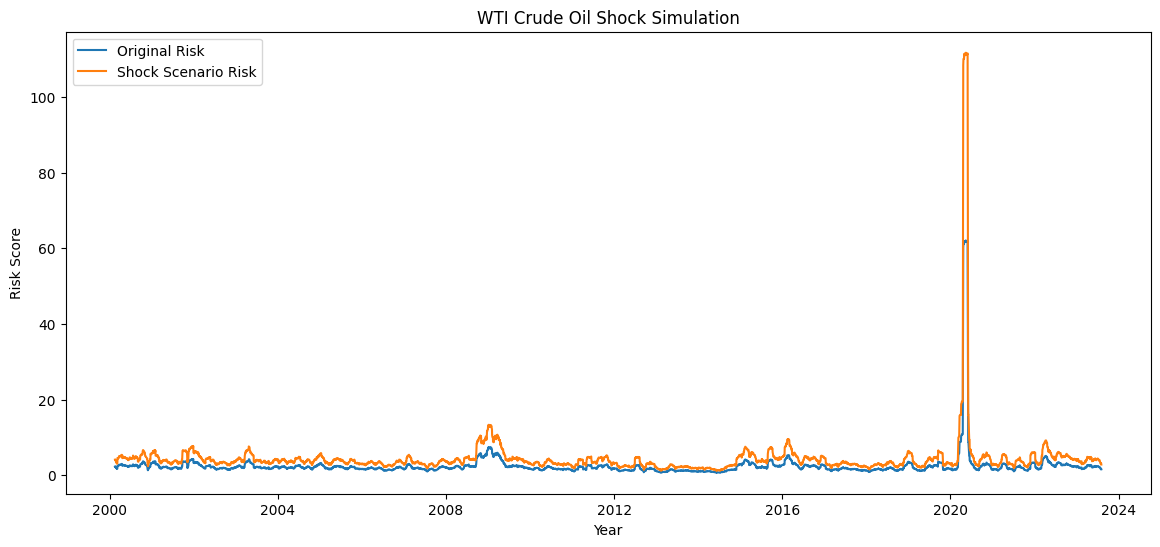

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    risk_scores['WTI CRUDE'],
    label='Original Risk'
)

plt.plot(
    oil_shock_df['WTI CRUDE'],
    label='Shock Scenario Risk'
)

plt.title("WTI Crude Oil Shock Simulation")

plt.xlabel("Year")
plt.ylabel("Risk Score")

plt.legend()

plt.show()

In [6]:
energy_crisis = risk_scores.copy()

energy_crisis['WTI CRUDE'] *= 1.7
energy_crisis['BRENT CRUDE'] *= 1.6
energy_crisis['NATURAL GAS'] *= 2.0

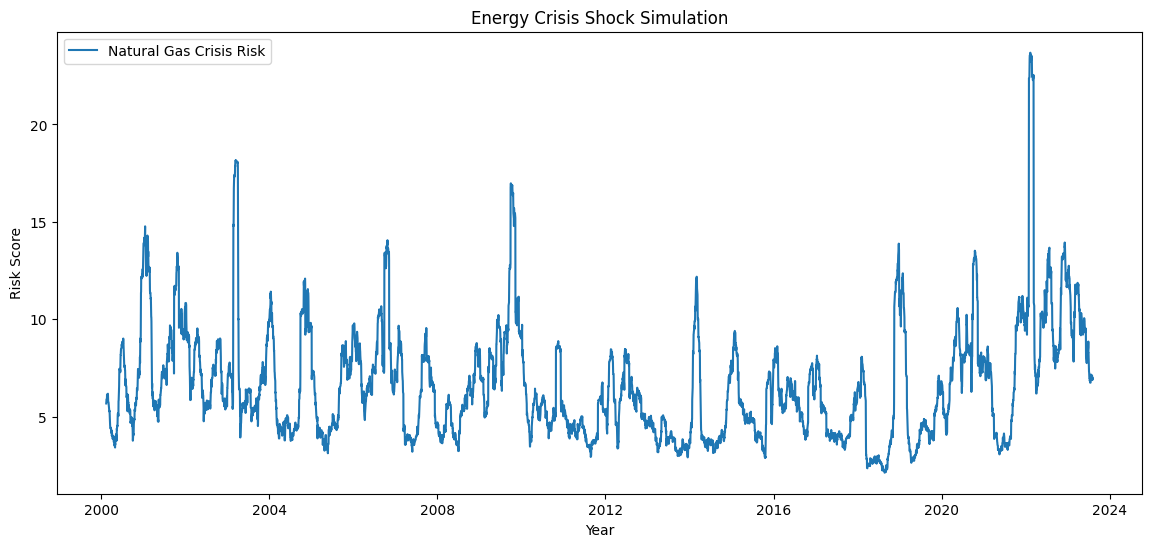

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    energy_crisis['NATURAL GAS'],
    label='Natural Gas Crisis Risk'
)

plt.title("Energy Crisis Shock Simulation")

plt.xlabel("Year")
plt.ylabel("Risk Score")

plt.legend()

plt.show()

In [8]:
portfolio_risk_before = risk_scores.mean(axis=1)

portfolio_risk_after = energy_crisis.mean(axis=1)

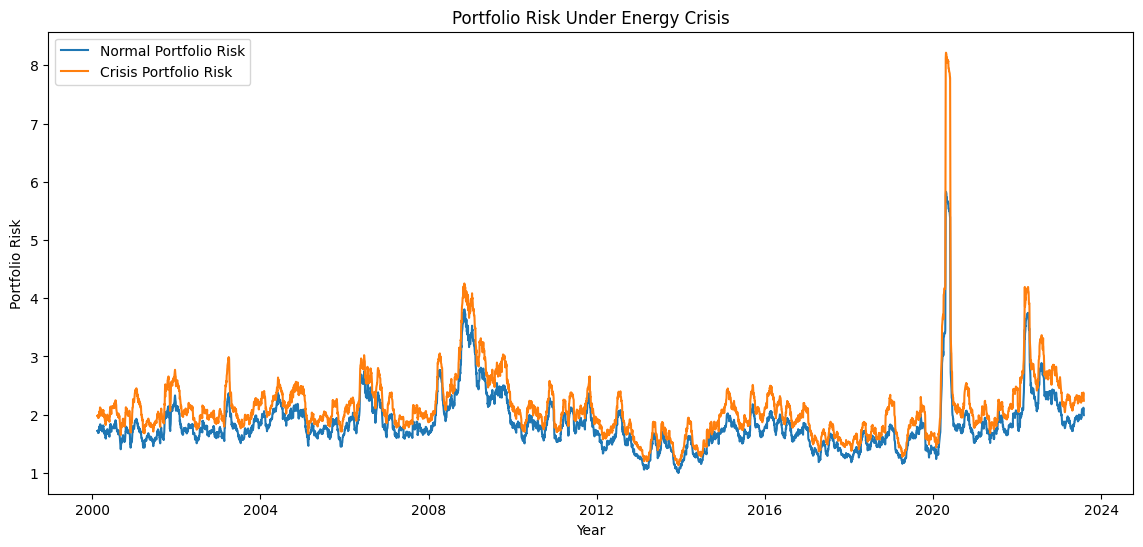

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    portfolio_risk_before,
    label='Normal Portfolio Risk'
)

plt.plot(
    portfolio_risk_after,
    label='Crisis Portfolio Risk'
)

plt.title("Portfolio Risk Under Energy Crisis")

plt.xlabel("Year")
plt.ylabel("Portfolio Risk")

plt.legend()

plt.show()

In [10]:
risk_increase = (
    portfolio_risk_after.mean()
    -
    portfolio_risk_before.mean()
)

print(f"""
Portfolio risk increased by 
{risk_increase:.2f}
points under the simulated energy crisis scenario.
""")


Portfolio risk increased by 
0.29
points under the simulated energy crisis scenario.



## Shock Simulation Insights

The simulation engine demonstrates how macroeconomic and geopolitical events can significantly amplify financial risk exposure across commodity portfolios.

Energy-related commodities exhibited the strongest response under crisis conditions, increasing systemic portfolio volatility.

In [11]:
energy_crisis.to_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/energy_crisis_simulation.csv"
)